#  🍄Mushroom Classification🍄

## 1. Importing Libraries

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# For better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print(" Libraries imported successfully!")

 Libraries imported successfully!


## 2. Data Loading

In [3]:
# Load the mushroom dataset from CSV
data = pd.read_csv('data/mushrooms.csv')

# Display basic info
print(" Data loaded successfully!")
print(f" Dataset Shape: {data.shape} (rows, columns)")
print(" First 5 Rows of the Dataset:")
display(data.head())

 Data loaded successfully!
 Dataset Shape: (8124, 23) (rows, columns)
 First 5 Rows of the Dataset:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3. Data Cleaning 

In [4]:
# Cell 4: Data Cleaning and Quality Check

# Step 1: Check for missing (null) values
print(" Checking for missing values:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print(" No missing values found in the dataset.")

# Step 2: Check for duplicate rows
print(f"\n Checking for duplicate rows:")
print(f"Number of duplicate rows: {data.duplicated().sum()}")

# Step 3: Remove duplicate rows
data_clean = data.drop_duplicates()
print(f" Duplicates removed. New dataset shape: {data_clean.shape}")

# Step 4: Verify the class distribution is correct
print(f"\n🍄 Final Class Distribution (should be only 'e' and 'p'):")
print(data_clean['class'].value_counts())

# Step 5: Display the first few rows of the cleaned data
print(f"\n First 5 Rows of the Cleaned Dataset:")
display(data_clean.head())

# Update the global 'data' variable to the cleaned version
data = data_clean

 Checking for missing values:
Series([], dtype: int64)
 No missing values found in the dataset.

 Checking for duplicate rows:
Number of duplicate rows: 0
 Duplicates removed. New dataset shape: (8124, 23)

🍄 Final Class Distribution (should be only 'e' and 'p'):
class
e    4208
p    3916
Name: count, dtype: int64

 First 5 Rows of the Cleaned Dataset:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 4. EDA

🍄 CLASS DISTRIBUTION (e = edible, p = poisonous)
class
e    4208
p    3916
Name: count, dtype: int64


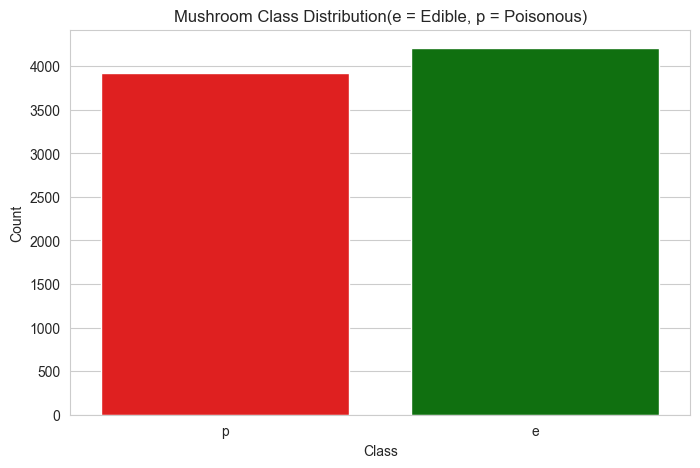


 Percentage of Each Class:
 Edible: 4208 mushrooms → 51.8%
 Poisonous: 3916 mushrooms → 48.2%


In [5]:
# Check class distribution
print("🍄 CLASS DISTRIBUTION (e = edible, p = poisonous)")
print(data['class'].value_counts())

# Plot count of each class with custom colors: green for 'e', red for 'p'
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=data, palette={'e': 'green', 'p': 'red'}, hue='class', legend=False)
plt.title("Mushroom Class Distribution(e = Edible, p = Poisonous)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Show percentages
edible_count = (data['class'] == 'e').sum()
poisonous_count = (data['class'] == 'p').sum()
total = len(data)

print(f"\n Percentage of Each Class:")
print(f" Edible: {edible_count} mushrooms → {edible_count / total * 100:.1f}%")
print(f" Poisonous: {poisonous_count} mushrooms → {poisonous_count / total * 100:.1f}%")

## 5. Preprocessing and Label Encoding

In [6]:
# Cell 5: Preprocessing – Label Encoding (Corrected)

from sklearn.preprocessing import LabelEncoder

# Create a copy for encoded data
data_encoded = data.copy()

# Dictionary to store encoders for each column
encoders = {}

# Apply label encoding to every column separately
for column in data_encoded.columns:
    le = LabelEncoder()
    data_encoded[column] = le.fit_transform(data_encoded[column])
    encoders[column] = le   # store encoder for later use in prediction

# Show results
print(" Label Encoding completed with individual encoders stored!")
print("\n First 5 rows of Original Data:")
display(data.head())

print("\n First 5 rows of Encoded Data:")
display(data_encoded.head())


 Label Encoding completed with individual encoders stored!

 First 5 rows of Original Data:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g



 First 5 rows of Encoded Data:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


## 6. Dependent/ Independent Split

In [7]:
# Define X (features) and y (target)
X = data_encoded.drop('class', axis=1) # All columns except 'class'
y = data_encoded['class'] # Target column: 0 = edible, 1 = poisonous

# Display shapes
print(f" Feature set (X) shape: {X.shape} → {X.shape[1]} features for {X.shape[0]} mushrooms")
print(f" Target set (y) shape: {y.shape}")

# Show first few rows for verification
print(f" First 5 rows of Features (X):")
display(X.head())

print(f" First 5 values of Target (y):")
display(y.head())

 Feature set (X) shape: (8124, 22) → 22 features for 8124 mushrooms
 Target set (y) shape: (8124,)
 First 5 rows of Features (X):


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,...,2,7,7,0,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,...,2,7,7,0,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,...,2,7,7,0,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,...,2,7,7,0,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,...,2,7,7,0,2,1,0,3,0,1


 First 5 values of Target (y):


0    1
1    0
2    0
3    1
4    0
Name: class, dtype: int32

## 7. Train-Test Split

In [8]:
# Cell 7: Train-Test Split
from sklearn.model_selection import train_test_split

# Split features and target into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y # Ensures balanced split
)

# Display split results
print(f" Training set size: {X_train.shape[0]} samples (features: {X_train.shape[1]})")
print(f" Testing set size: {X_test.shape[0]} samples")
print(f" Class distribution in training set:")
print(y_train.value_counts())
print(f" Class distribution in testing set:")
print(y_test.value_counts())

 Training set size: 5686 samples (features: 22)
 Testing set size: 2438 samples
 Class distribution in training set:
class
0    2945
1    2741
Name: count, dtype: int64
 Class distribution in testing set:
class
0    1263
1    1175
Name: count, dtype: int64


### HeatMap

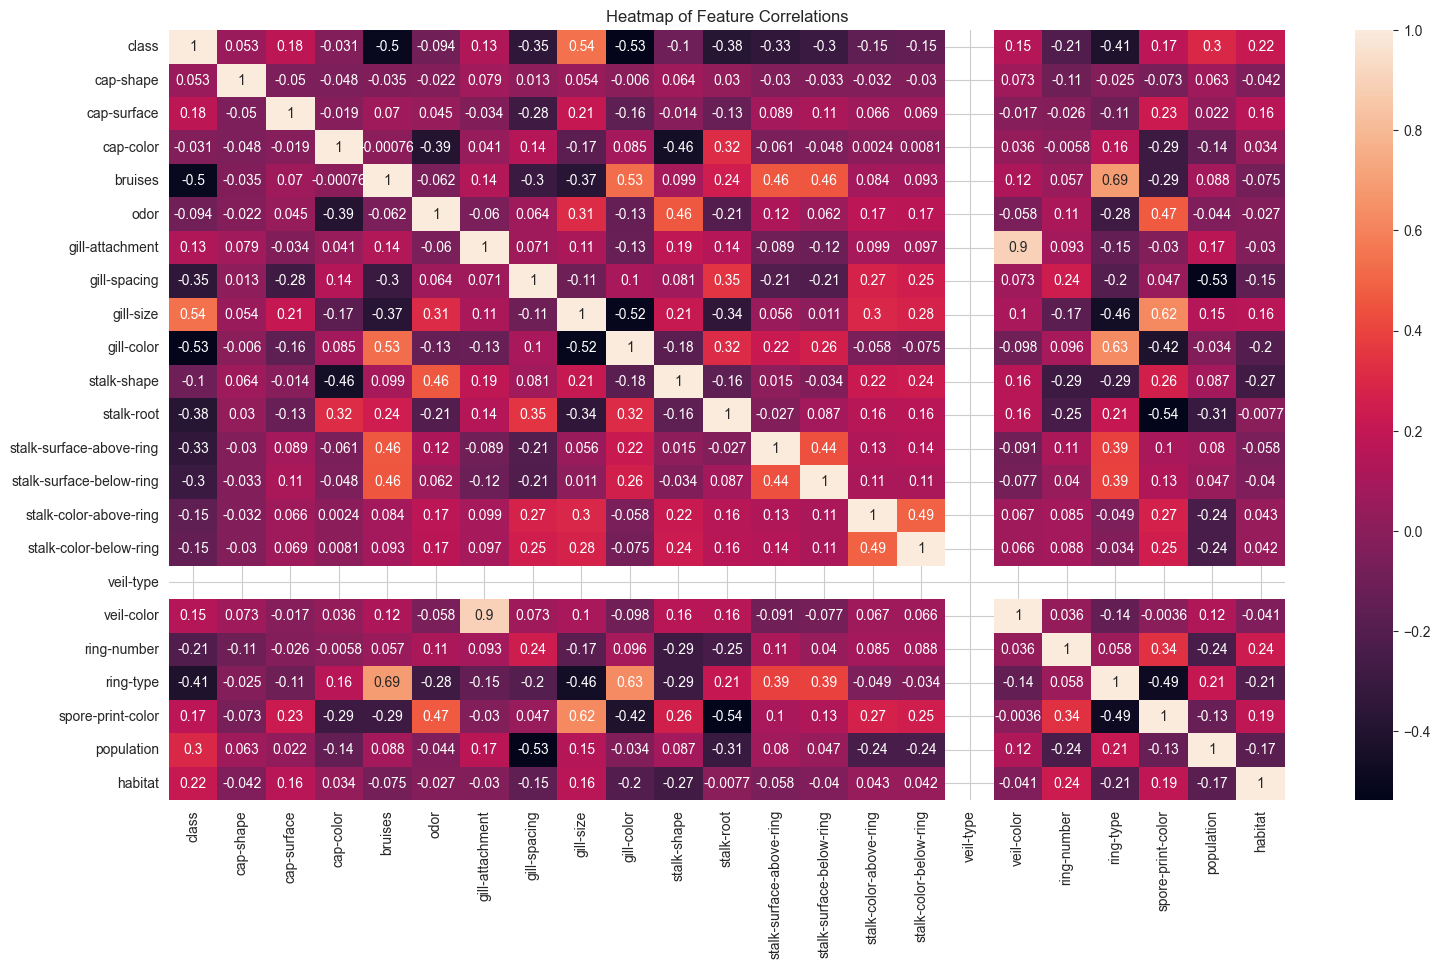

In [9]:
# Cell E2: Heatmap of Feature Correlations

import seaborn as sns

plt.figure(figsize=(18,10))
corr = data_encoded.corr()
sns.heatmap(corr, annot=True, cbar=True)
plt.title("Heatmap of Feature Correlations")
plt.show()


## 8. Model Training and Evaluation

### Logistic Regression

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_logreg

array([1, 1, 0, ..., 0, 0, 1])

 Training Logistic Regression...
Logistic Regression Accuracy: 0.9594

Classification Report:
              precision    recall  f1-score   support

      Edible       0.96      0.96      0.96      1263
   Poisonous       0.96      0.96      0.96      1175

    accuracy                           0.96      2438
   macro avg       0.96      0.96      0.96      2438
weighted avg       0.96      0.96      0.96      2438



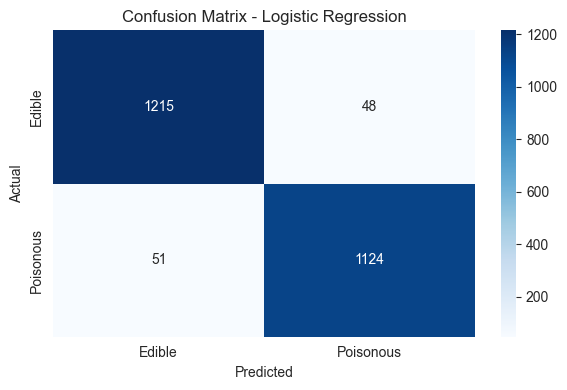

In [13]:
# Cell 8C: Logistic Regression

from sklearn.linear_model import LogisticRegression

print(" Training Logistic Regression...")

# Initialize model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train using scaled data
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred = lr_model.predict(X_test_scaled)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### Random Forest

In [14]:
# Cell: Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Show parameters
rf_model

# Train model
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


 Training Random Forest...
 Random Forest Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00      1263
   Poisonous       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



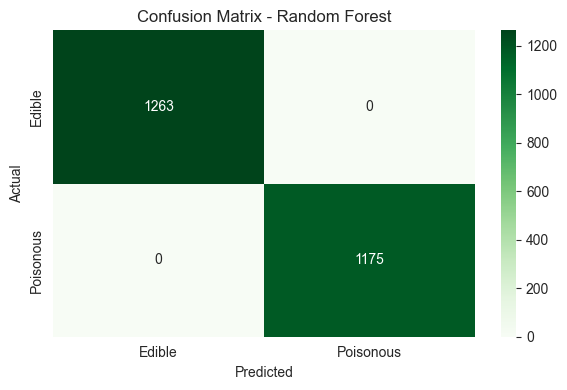

In [15]:
# Cell 8A: Random Forest Classifier


print(" Training Random Forest...")

# Initialize model with parameters
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f" Random Forest Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### Decision Tree

In [16]:
# Cell: Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Show parameters
dt_model

# Train model
dt_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


 Training Decision Tree...
 Decision Tree Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00      1263
   Poisonous       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



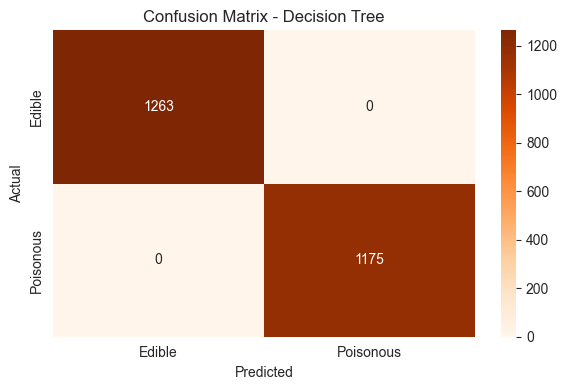

In [17]:
# Cell 8B: Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

print(" Training Decision Tree...")

# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict
y_pred = dt_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f" Decision Tree Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### SVM

In [18]:
# Cell: Support Vector Machine (SVM)

from sklearn.svm import SVC

# Initialize model
svm_model = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

# Show parameters
svm_model

# Train model
svm_model.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


 Training Support Vector Machine...
 SVM Accuracy: 0.9799

Classification Report:
              precision    recall  f1-score   support

      Edible       0.98      0.98      0.98      1263
   Poisonous       0.98      0.98      0.98      1175

    accuracy                           0.98      2438
   macro avg       0.98      0.98      0.98      2438
weighted avg       0.98      0.98      0.98      2438



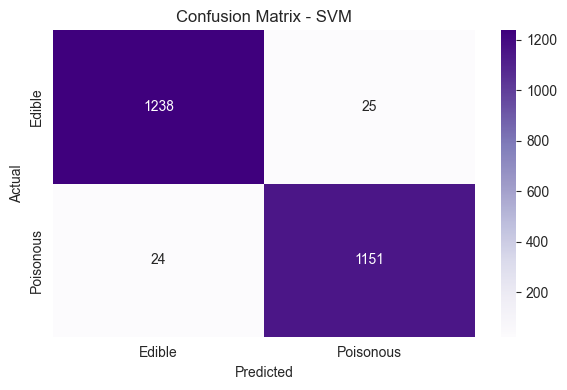

In [19]:
# Cell 8D: Support Vector Machine (SVM)

from sklearn.svm import SVC

print(" Training Support Vector Machine...")

# Initialize model
svm_model = SVC(
    kernel='linear',
    probability=True,   # enable predict_proba if needed
    random_state=42
)

# Train using scaled data
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred = svm_model.predict(X_test_scaled)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f" SVM Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [20]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='linear', random_state=42)
}

results = {}
print("🚀 Training models...\n")

for name, model in models.items():
    # Use scaled data for Logistic Regression and SVM
    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

🚀 Training models...



## 9. Model Comparison

 Model Comparison (Sorted by Accuracy)
                 Model  Accuracy
0        Random Forest  1.000000
1        Decision Tree  1.000000
3                  SVM  0.979902
2  Logistic Regression  0.959393


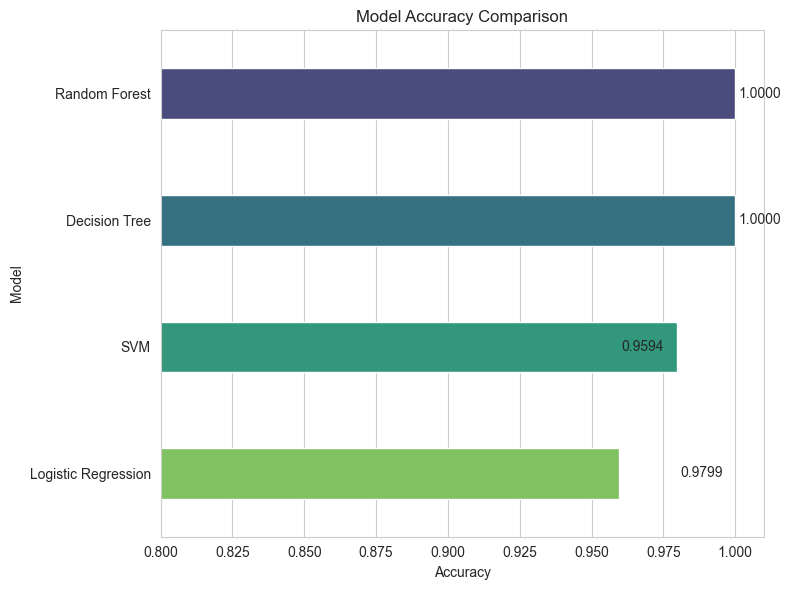

In [21]:
# Cell 9: Model Comparison - Thinner Bars
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for comparison
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)

# Display results
print(" Model Comparison (Sorted by Accuracy)")
print(results_df)

# Plot model comparison with thinner bars
plt.figure(figsize=(8, 6))
sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model',
    hue='Model', # Required for palette in new Seaborn
    palette='viridis',
    legend=False,
    width=0.4 # Thinner bars
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.xlim(0.8, 1.01) # Most models are near 100%

# Add accuracy labels on bars
for index, row in results_df.iterrows():
    plt.text(row['Accuracy'] + 0.001, index, f"{row['Accuracy']:.4f}", va='center')

plt.tight_layout()
plt.show()

                 Model  Accuracy    Recall  F1-score
0  Logistic Regression  0.959393  0.956596  0.957818
1        Random Forest  1.000000  1.000000  1.000000
2        Decision Tree  1.000000  1.000000  1.000000
3                  SVM  0.979902  0.979574  0.979158


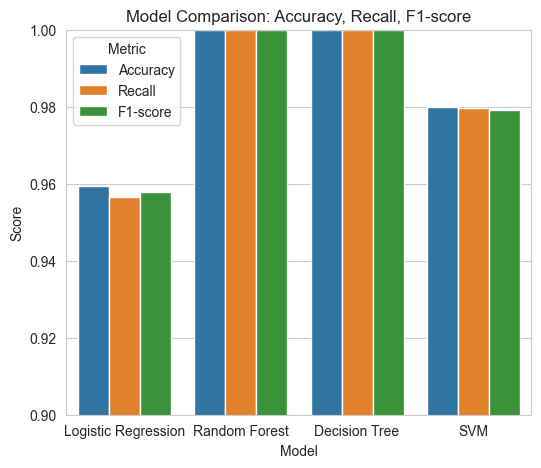

In [22]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Collect predictions from each trained model
preds = {
    "Logistic Regression": lr_model.predict(X_test_scaled),
    "Random Forest": rf_model.predict(X_test),
    "Decision Tree": dt_model.predict(X_test),
    "SVM": svm_model.predict(X_test_scaled)
}

# Evaluate models
results = []
for name, y_pred in preds.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred, pos_label=1),
        "F1-score": f1_score(y_test, y_pred, pos_label=1)
    })

# Create summary table
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

# Optional: plot comparison
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.barplot(data=results_df.melt(id_vars="Model", var_name="Metric", value_name="Score"),
            x="Model", y="Score", hue="Metric")
plt.title("Model Comparison: Accuracy, Recall, F1-score")
plt.ylim(0.9, 1.0)  # since all scores are very high in this dataset
plt.show()


## 10. Model Prediction

In [22]:
def predict_mushroom():
    print("🍄 MUSHROOM EDIBILITY PREDICTOR")
    print("Enter a single-letter code for each feature as shown in the hints.\n")
    
    # Full feature hints
    feature_hints = {
        'cap-shape': 'bell=b, conical=c, convex=x, flat=f, knobbed=k, sunken=s',
        'cap-surface': 'fibrous=f, grooves=g, scaly=y, smooth=s',
        'cap-color': 'brown=n, buff=b, cinnamon=c, gray=g, green=r, pink=p, purple=u, red=e, white=w, yellow=y',
        'bruises': 'yes=t, no=f',
        'odor': 'almond=a, anise=l, creosote=c, fishy=y, foul=f, musty=m, none=n, pungent=p, spicy=s',
        'gill-attachment': 'attached=a, free=f, descending=d, notched=n',
        'gill-spacing': 'close=c, crowded=w, distant=d',
        'gill-size': 'broad=b, narrow=n',
        'gill-color': 'black=k, brown=n, buff=b, chocolate=h, gray=g, green=r, orange=o, pink=p, purple=u, red=e, white=w, yellow=y',
        'stalk-shape': 'enlarging=e, tapering=t',
        'stalk-root': 'bulbous=b, club=c, cup=u, equal=e, rhizomorphs=z, rooted=r, missing=?',
        'stalk-surface-above-ring': 'fibrous=f, scaly=y, silky=k, smooth=s',
        'stalk-surface-below-ring': 'fibrous=f, scaly=y, silky=k, smooth=s',
        'stalk-color-above-ring': 'brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y',
        'stalk-color-below-ring': 'brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y',
        'veil-type': 'partial=p, universal=u',
        'veil-color': 'brown=n, orange=o, white=w, yellow=y',
        'ring-number': 'none=n, one=o, two=t',
        'ring-type': 'cobwebby=c, evanescent=e, flaring=f, large=l, none=n, pendant=p, sheathing=s, zone=z',
        'spore-print-color': 'black=k, brown=n, buff=b, chocolate=h, green=r, orange=o, purple=u, white=w, yellow=y',
        'population': 'abundant=a, clustered=c, numerous=n, scattered=s, several=v, solitary=y',
        'habitat': 'grasses=g, leaves=l, meadows=m, paths=p, urban=u, waste=w, woods=d'
    }
    
    # Collect user input
    user_input = []
    for feature, hint in feature_hints.items():
        while True:
            val = input(f"{feature} [{hint}]: ").strip().lower()
            print(f" You entered: '{val}' for '{feature}'")
            valid_options = [x.strip().split('=')[1] for x in hint.split(',') if '=' in x]
            if len(val) == 1 and val in valid_options:
                user_input.append(val)
                break
            else:
                print(f"⚠️ Invalid input. Please use a single letter from the hint (e.g., 'x', 's', 't').")
    
    # Create DataFrame
    user_df = pd.DataFrame([user_input], columns=feature_hints.keys())

    # Encode user input with stored encoders
    for col in feature_hints.keys():
        le = encoders[col]
        user_val = user_df[col].iloc[0]
        if user_val in le.classes_:
            user_df[col] = le.transform([user_val])[0]
        else:
            print(f" '{user_val}' not valid for '{col}'. Using 0 as default.")
            user_df[col] = 0

    # Match training feature order
    feature_order = X_train.columns.tolist()
    user_df = user_df[feature_order]

    # Predict
    try:
        prediction = rf_model.predict(user_df)[0]
        proba = rf_model.predict_proba(user_df)[0]
        confidence = max(proba) * 100
    except NameError:
        print(" Error: Model 'rf_model' not found. Please run the model training cell first.")
        return
    except Exception as e:
        print(f" Prediction error: {e}")
        return

    # Decode result using target encoder
    result_label = encoders['class'].inverse_transform([prediction])[0]

    # Output
    print("\n" + "="*50)
    print(" 🧠 FINAL PREDICTION")
    print("="*50)
    print(f" Mushroom is: {result_label.upper()}")
    print(f" Confidence: {confidence:.1f}%")
    print("="*50)
    if result_label == "p":
        print(" ⚠️ DO NOT EAT — This mushroom is predicted to be POISONOUS!")
    else:
        print(" ✅ This mushroom is likely edible — but always verify with an expert.")
    print("="*50)

# Run it
predict_mushroom()


🍄 MUSHROOM EDIBILITY PREDICTOR
Enter a single-letter code for each feature as shown in the hints.

 You entered: 'x' for 'cap-shape'
 You entered: 's' for 'cap-surface'
 You entered: 'n' for 'cap-color'
 You entered: 't' for 'bruises'
 You entered: 'n' for 'odor'
 You entered: 'f' for 'gill-attachment'
 You entered: 'c' for 'gill-spacing'
 You entered: 'b' for 'gill-size'
 You entered: 'c' for 'gill-color'
⚠️ Invalid input. Please use a single letter from the hint (e.g., 'x', 's', 't').
 You entered: 'e' for 'gill-color'
 You entered: 'e' for 'stalk-shape'
 You entered: 's' for 'stalk-root'
⚠️ Invalid input. Please use a single letter from the hint (e.g., 'x', 's', 't').
 You entered: 's' for 'stalk-root'
⚠️ Invalid input. Please use a single letter from the hint (e.g., 'x', 's', 't').
 You entered: 'w' for 'stalk-root'
⚠️ Invalid input. Please use a single letter from the hint (e.g., 'x', 's', 't').
 You entered: 'w' for 'stalk-root'
⚠️ Invalid input. Please use a single letter from t